# Phase 2 — Step 2: Delivery Time Analysis

**Goal:** Load 96,000+ real Olist orders, join with customer state data using DuckDB SQL, engineer delivery metrics with Polars, and find where delays happen.

**Stack:** DuckDB · Polars · Matplotlib

> Each CSV is loaded with `usecols` equivalent — only the columns we actually use — to keep memory low.

In [ ]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, warnings
warnings.filterwarnings("ignore")

FIGURES  = "../data/figures"
DB_PATH  = "../data/apex.duckdb"
CSV_OUT  = "../data/delivery_analysis.csv"
os.makedirs(FIGURES, exist_ok=True)
print("Setup complete.")


Setup complete.


In [ ]:
# ── Load only the columns we need (memory efficient) ─────────────────────────
orders = pl.read_csv("../data/olist_orders_dataset.csv",
    columns=["order_id", "customer_id", "order_status",
             "order_purchase_timestamp", "order_delivered_customer_date",
             "order_estimated_delivery_date"])

customers = pl.read_csv("../data/olist_customers_dataset.csv",
    columns=["customer_id", "customer_state"])

# ── Join via DuckDB SQL ───────────────────────────────────────────────────────
conn = duckdb.connect()   # in-memory for this join
conn.register("orders",    orders)
conn.register("customers", customers)

df = conn.execute('''
    SELECT o.order_id, o.order_status,
           o.order_purchase_timestamp,
           o.order_delivered_customer_date,
           o.order_estimated_delivery_date,
           c.customer_state
    FROM   orders    o
    LEFT   JOIN customers c USING (customer_id)
    WHERE  o.order_status = 'delivered'
      AND  o.order_delivered_customer_date IS NOT NULL
      AND  o.order_estimated_delivery_date IS NOT NULL
''').pl()
conn.close()
del orders, customers

print(f"Delivered orders loaded : {len(df):,}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Delivered orders loaded : 96,470


In [ ]:
# ── Brazilian state code → full name (for Power BI geocoding) ─────────────────
BR_STATES = {
    "AC":"Acre","AL":"Alagoas","AP":"Amapá","AM":"Amazonas",
    "BA":"Bahia","CE":"Ceará","DF":"Distrito Federal","ES":"Espírito Santo",
    "GO":"Goiás","MA":"Maranhão","MT":"Mato Grosso","MS":"Mato Grosso do Sul",
    "MG":"Minas Gerais","PA":"Pará","PB":"Paraíba","PR":"Paraná",
    "PE":"Pernambuco","PI":"Piauí","RJ":"Rio de Janeiro","RN":"Rio Grande do Norte",
    "RS":"Rio Grande do Sul","RO":"Rondônia","RR":"Roraima","SC":"Santa Catarina",
    "SP":"São Paulo","SE":"Sergipe","TO":"Tocantins",
}

# ── Delivery metrics with Polars ──────────────────────────────────────────────
df = df.with_columns([
    pl.col("order_purchase_timestamp").str.to_datetime("%Y-%m-%d %H:%M:%S", strict=False).alias("purchased"),
    pl.col("order_delivered_customer_date").str.to_datetime("%Y-%m-%d %H:%M:%S", strict=False).alias("delivered"),
    pl.col("order_estimated_delivery_date").str.to_datetime("%Y-%m-%d %H:%M:%S", strict=False).alias("estimated"),
])

# Validate: warn if any timestamps failed to parse
for col in ["purchased", "delivered", "estimated"]:
    null_count = df[col].null_count()
    if null_count > 0:
        print(f"WARNING: {null_count} nulls in '{col}' after datetime parse — rows will be excluded")

# Drop rows where any date failed to parse
before = len(df)
df = df.drop_nulls(subset=["purchased", "delivered", "estimated"])
dropped = before - len(df)
if dropped > 0:
    print(f"Dropped {dropped} rows with unparseable dates")

df = df.with_columns([
    ((pl.col("delivered") - pl.col("purchased")).dt.total_seconds() / 86400)
        .round(1).alias("delivery_days"),
    ((pl.col("delivered") - pl.col("estimated")).dt.total_seconds() / 86400)
        .round(1).alias("days_vs_estimate"),
])
df = df.with_columns([
    (pl.col("days_vs_estimate") > 0).cast(pl.Int32).alias("is_late"),
    pl.col("purchased").dt.strftime("%Y-%m").alias("purchase_month"),
    # Full state name for Power BI geocoding (no ambiguity with 2-letter codes)
    pl.col("customer_state").replace(BR_STATES).alias("state_name"),
    pl.lit("Brazil").alias("country"),
])

# Drop raw date columns — audit note: filter was order_status = 'delivered' (applied in load cell)
df = df.drop(["order_purchase_timestamp","order_delivered_customer_date",
              "order_estimated_delivery_date","order_status","purchased","delivered","estimated"])

avg_days = df["delivery_days"].mean()
late_pct = df["is_late"].mean()
print(f"Avg delivery   : {avg_days:.1f} days")
print(f"Median delivery: {df['delivery_days'].median():.0f} days")
print(f"Late rate      : {late_pct:.1%}  ({df['is_late'].sum():,} orders)")

# Sanity check — delivery_days should be positive and realistic
invalid_days = df.filter((pl.col("delivery_days") <= 0) | (pl.col("delivery_days") > 365))
if len(invalid_days) > 0:
    print(f"WARNING: {len(invalid_days)} rows with delivery_days outside 0-365 range")


Avg delivery   : 12.6 days
Median delivery: 10 days
Late rate      : 8.0%  (7,765 orders)


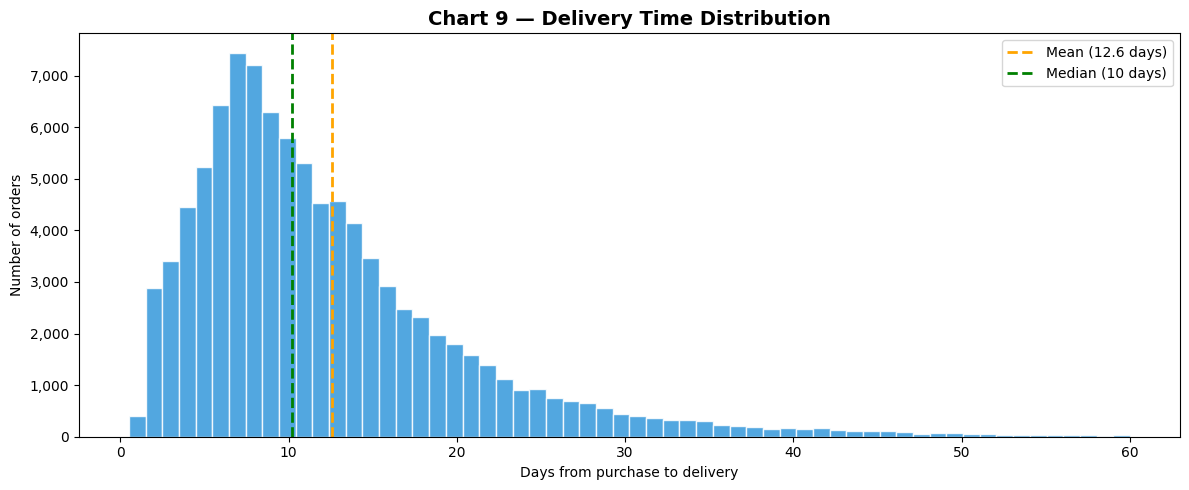

Chart 9 saved.


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
data = df.filter(pl.col("delivery_days").is_between(0, 60))["delivery_days"].to_numpy()
ax.hist(data, bins=60, color="#3498db", edgecolor="white", alpha=0.85)
ax.axvline(df["delivery_days"].mean(),   color="orange", linestyle="--", linewidth=2,
           label=f'Mean ({df["delivery_days"].mean():.1f} days)')
ax.axvline(df["delivery_days"].median(), color="green",  linestyle="--", linewidth=2,
           label=f'Median ({df["delivery_days"].median():.0f} days)')
ax.set_title("Chart 9 — Delivery Time Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Days from purchase to delivery")
ax.set_ylabel("Number of orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/chart9_delivery_distribution.png", dpi=150)
plt.show()
print("Chart 9 saved.")


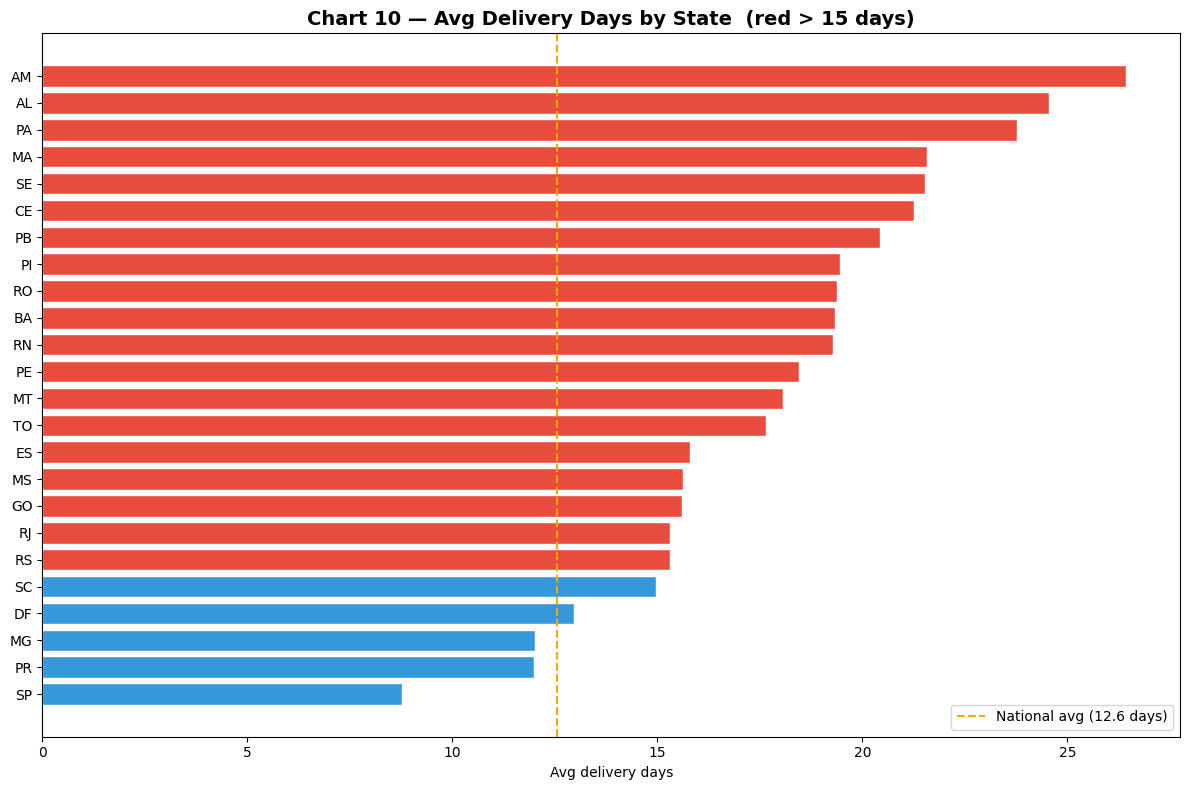

Chart 10 saved.


In [ ]:
state_df = (df.group_by("customer_state")
              .agg([pl.col("delivery_days").mean().alias("avg_days"),
                    pl.len().alias("orders")])
              .filter(pl.col("orders") >= 100)
              .sort("avg_days"))

nat_avg  = df["delivery_days"].mean()
states   = state_df["customer_state"].to_list()
avgs     = state_df["avg_days"].to_list()
colors   = ["#e74c3c" if v > 15 else "#3498db" for v in avgs]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(states, avgs, color=colors, edgecolor="white")
ax.axvline(nat_avg, color="orange", linestyle="--", linewidth=1.5,
           label=f"National avg ({nat_avg:.1f} days)")
ax.set_title("Chart 10 — Avg Delivery Days by State  (red > 15 days)", fontsize=14, fontweight="bold")
ax.set_xlabel("Avg delivery days")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/chart10_delivery_by_state.png", dpi=150)
plt.show()
print("Chart 10 saved.")


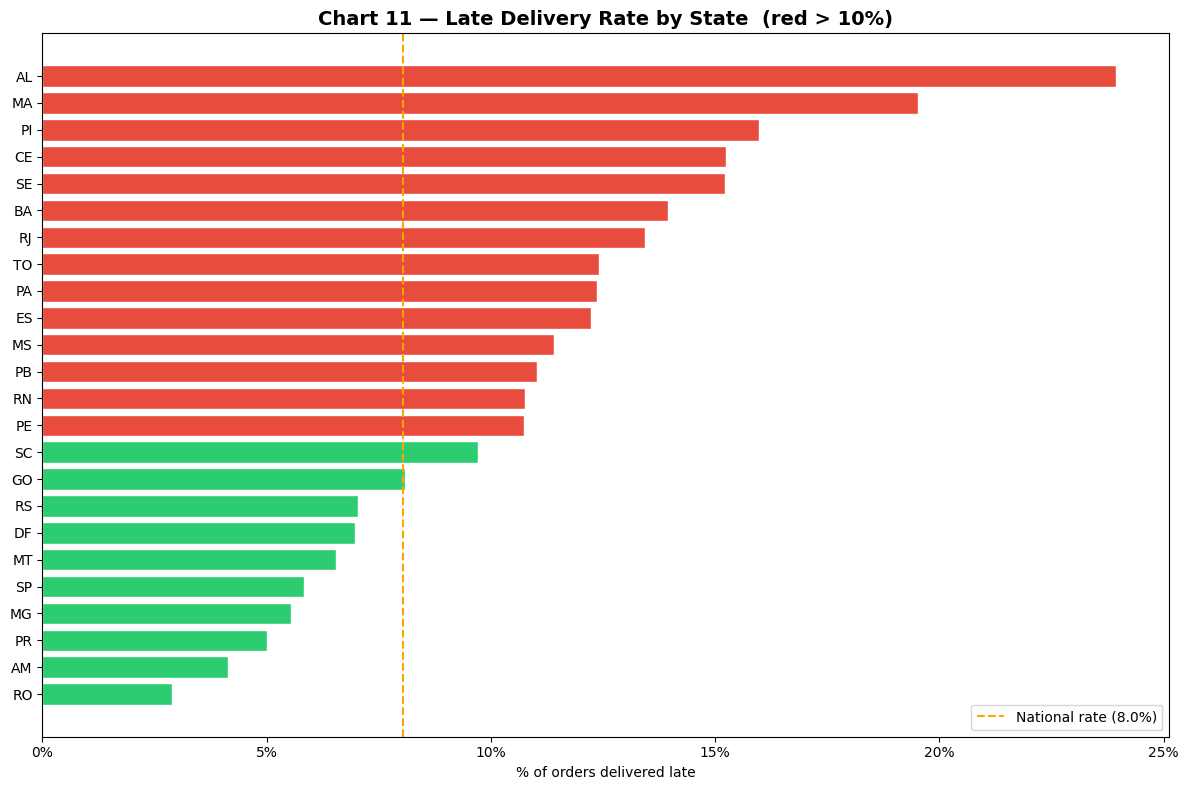

Chart 11 saved.


In [ ]:
late_df = (df.group_by("customer_state")
             .agg([pl.col("is_late").mean().alias("late_rate"),
                   pl.len().alias("orders")])
             .filter(pl.col("orders") >= 100)
             .with_columns((pl.col("late_rate") * 100).alias("late_pct"))
             .sort("late_pct"))

states = late_df["customer_state"].to_list()
pcts   = late_df["late_pct"].to_list()
colors = ["#e74c3c" if v > 10 else "#2ecc71" for v in pcts]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(states, pcts, color=colors, edgecolor="white")
ax.axvline(df["is_late"].mean() * 100, color="orange", linestyle="--", linewidth=1.5,
           label=f"National rate ({df['is_late'].mean():.1%})")
ax.set_title("Chart 11 — Late Delivery Rate by State  (red > 10%)", fontsize=14, fontweight="bold")
ax.set_xlabel("% of orders delivered late")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/chart11_late_rate_by_state.png", dpi=150)
plt.show()
print("Chart 11 saved.")


In [ ]:
# ── Power BI enrichment — extra columns for richer visuals ───────────────────
REGION_MAP = {
    "SP": "Southeast", "RJ": "Southeast", "MG": "Southeast", "ES": "Southeast",
    "RS": "South",     "PR": "South",     "SC": "South",
    "BA": "Northeast", "PE": "Northeast", "CE": "Northeast", "MA": "Northeast",
    "PA": "North",     "AM": "North",     "RR": "North",     "AP": "North",
    "GO": "Centre-West", "MT": "Centre-West", "MS": "Centre-West", "DF": "Centre-West",
    "AL": "Northeast", "RN": "Northeast", "PB": "Northeast", "PI": "Northeast",
    "SE": "Northeast", "TO": "North",     "RO": "North",     "AC": "North",
}

df = df.with_columns([
    pl.when(pl.col("delivery_days") <= 5).then(pl.lit("1-5 days"))
      .when(pl.col("delivery_days") <= 10).then(pl.lit("6-10 days"))
      .when(pl.col("delivery_days") <= 15).then(pl.lit("11-15 days"))
      .when(pl.col("delivery_days") <= 20).then(pl.lit("16-20 days"))
      .when(pl.col("delivery_days") <= 25).then(pl.lit("21-25 days"))
      .otherwise(pl.lit("25+ days")).alias("delivery_bucket"),

    pl.when(pl.col("days_vs_estimate") < -1).then(pl.lit("Early"))
      .when(pl.col("days_vs_estimate") <= 0).then(pl.lit("On time"))
      .when(pl.col("days_vs_estimate") <= 3).then(pl.lit("1-3 days late"))
      .otherwise(pl.lit("3+ days late")).alias("estimate_label"),

    pl.col("purchase_month").str.to_datetime("%Y-%m").dt.strftime("%b %Y").alias("month_name"),
    # literal=True avoids regex interpretation — required in Polars 1.x
    pl.col("purchase_month").str.replace("-", "", literal=True).cast(pl.Int32).alias("month_sort"),

    (pl.col("days_vs_estimate") < 0).cast(pl.Int32).alias("is_early"),
    pl.col("days_vs_estimate").clip(lower_bound=0).alias("days_late"),

    pl.col("customer_state").replace(REGION_MAP).fill_null("Other").alias("region"),

    pl.when(pl.col("delivery_days") <= 7).then(pl.lit("Fast"))
      .when(pl.col("delivery_days") <= 14).then(pl.lit("Normal"))
      .when(pl.col("delivery_days") <= 21).then(pl.lit("Slow"))
      .otherwise(pl.lit("Critical")).alias("performance_flag"),
])

# ── Save ──────────────────────────────────────────────────────────────────────
OUTPUT_COLS = [
    "order_id", "customer_state", "state_name", "country", "region",
    "delivery_days", "days_vs_estimate", "is_late", "is_early", "days_late",
    "delivery_bucket", "estimate_label", "performance_flag",
    "purchase_month", "month_name", "month_sort",
]

with duckdb.connect(DB_PATH) as conn2:
    conn2.register("delivery_df", df.select(OUTPUT_COLS))
    conn2.execute("CREATE OR REPLACE TABLE delivery AS SELECT * FROM delivery_df")

df.select(OUTPUT_COLS).write_csv(CSV_OUT)

fastest = state_df.sort("avg_days").row(0)
slowest = state_df.sort("avg_days", descending=True).row(0)
print("=" * 55)
print("  DELIVERY SUMMARY")
print("=" * 55)
print(f"  Orders           : {len(df):,}")
print(f"  Columns          : {len(OUTPUT_COLS)}  {OUTPUT_COLS}")
print(f"  Avg delivery     : {df['delivery_days'].mean():.1f} days")
print(f"  Late rate        : {df['is_late'].mean():.1%}")
print(f"  Fastest state    : {fastest[0]}  ({fastest[1]:.1f} days)")
print(f"  Slowest state    : {slowest[0]}  ({slowest[1]:.1f} days)")
print("=" * 55)
print(f"CSV  →  {CSV_OUT}")


  DELIVERY SUMMARY
  Orders           : 96,470
  Columns          : 16  ['order_id', 'customer_state', 'state_name', 'country', 'region', 'delivery_days', 'days_vs_estimate', 'is_late', 'is_early', 'days_late', 'delivery_bucket', 'estimate_label', 'performance_flag', 'purchase_month', 'month_name', 'month_sort']
  Avg delivery     : 12.6 days
  Late rate        : 8.0%
  Fastest state    : SP  (8.8 days)
  Slowest state    : AM  (26.4 days)
CSV  →  ../data/delivery_analysis.csv
